In [21]:
import pandas as pd
import numpy as np
from glob import glob
from tqdm import tqdm
import seaborn as sns
import matplotlib
%matplotlib inline
matplotlib.rc('pdf', fonttype=42)

blackboxdir = '../../datasets/blackbox/'
firstprincdir = '../../datasets/firstprinciples/'
frames = []
for ddir in [firstprincdir, blackboxdir]:
    print("Loading from", ddir)
    for f in tqdm(glob(ddir+'/*/*.tsv.gz')):
        # print(f)

        df = pd.read_csv(f, sep='\t')
        group = 'Feynman' if 'feynman' in f else \
                'Strogatz' if 'strogatz' in f else \
                'Friedman' if '_fri_' in f else \
                'First-principles' if 'principles_' in f else 'Black-box'
        
        # display(df)
        # Get statistics for numeric columns
        numeric_stats = df.select_dtypes(include=[np.number]).agg(['min', 'max'])
        
        frames.append(dict(
            name=f.split('/')[-1][:-7],
            nsamples=df.shape[0],
            nfeatures=df.shape[1],
            npoints=df.shape[0]*df.shape[1],
            group=group,
            # feature_ranges=str(numeric_stats.round(2).to_dict('list'))
        ))
    
df = pd.DataFrame.from_records(frames).sort_values(['group', 'name'])

display(df)

latex_table = df.drop(columns=['npoints']).to_latex(
    index=False,
    column_format="lrrr",
    escape=True
)

print(latex_table)

Loading from ../../datasets/firstprinciples/


100%|██████████| 13/13 [00:00<00:00, 68.03it/s]

Loading from ../../datasets/blackbox/



  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 14.75it/s]


,name,nsamples,nfeatures,npoints,group
13,1028_SWD,1000,11,11000,Black-box
14,1089_USCrime,47,14,658,Black-box
15,1193_BNG_lowbwt,31104,10,311040,Black-box
16,1199_BNG_echoMonths,17496,10,174960,Black-box
17,192_vineyard,52,3,156,Black-box
18,210_cloud,108,6,648,Black-box
19,522_pm10,500,8,4000,Black-box
20,557_analcatdata_apnea1,475,4,1900,Black-box
24,678_visualizing_environmental,111,4,444,Black-box
0,first_principles_absorption,14,2,28,First-principles


\begin{tabular}{lrrr}
\toprule
name & nsamples & nfeatures & group \\
\midrule
1028\_SWD & 1000 & 11 & Black-box \\
1089\_USCrime & 47 & 14 & Black-box \\
1193\_BNG\_lowbwt & 31104 & 10 & Black-box \\
1199\_BNG\_echoMonths & 17496 & 10 & Black-box \\
192\_vineyard & 52 & 3 & Black-box \\
210\_cloud & 108 & 6 & Black-box \\
522\_pm10 & 500 & 8 & Black-box \\
557\_analcatdata\_apnea1 & 475 & 4 & Black-box \\
678\_visualizing\_environmental & 111 & 4 & Black-box \\
first\_principles\_absorption & 14 & 2 & First-principles \\
first\_principles\_bode & 8 & 2 & First-principles \\
first\_principles\_hubble & 32 & 2 & First-principles \\
first\_principles\_ideal\_gas & 30 & 4 & First-principles \\
first\_principles\_kepler & 6 & 2 & First-principles \\
first\_principles\_leavitt & 26 & 2 & First-principles \\
first\_principles\_newton & 30 & 4 & First-principles \\
first\_principles\_planck & 100 & 3 & First-principles \\
first\_principles\_rydberg & 50 & 3 & First-principles \\
first\_princi

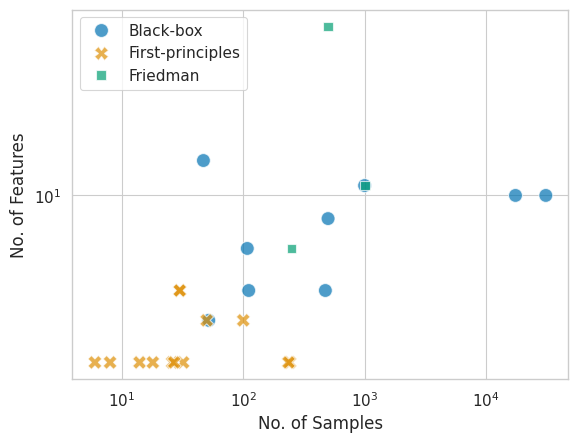

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

matplotlib.rc("pdf", fonttype=42)
matplotlib.rc("ps", fonttype=42)

sns.set(palette="colorblind", style='whitegrid')
sns.set_context("paper", font_scale=1.25, rc={"lines.linewidth": 1.1})

## PMLB dataset sizes
g = sns.scatterplot(
    data=df,
    x='nsamples',
    y='nfeatures',
    hue='group',
    style='group',
    alpha=0.7,
    s=100, 
)
ax = plt.gca()
plt.legend(loc='upper left')
ax.set_xscale('log')
ax.set_yscale('log')
plt.xlabel('No. of Samples')
plt.ylabel('No. of Features')

plt.savefig('../figs/pmlb_size.png',dpi=400, bbox_inches='tight')